In [1]:
%pip install liac-arff
%pip install xgboost
%pip install shap





[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Required libraries
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc
os.getcwd()


'/Users/odettesaenz/CS329E/FinalProject'

In [3]:
import arff
import pandas as pd
import os

# Set file path for ARFF file
file_path = "/Users/odettesaenz/Downloads/SpeedDating.arff"

# Load ARFF data and convert to DataFrame
with open(file_path, "r") as f:
    data = arff.load(f)

df = pd.DataFrame(data["data"], columns=[attr[0] for attr in data["attributes"]])

# Drop rows with missing target values and process target
df = df.dropna(subset=['match'])
target = df['match'].map({'no': 0, 'yes': 1})



In [4]:
print(df.columns)


Index(['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age',
       'race', 'race_o', 'samerace',
       ...
       'd_expected_num_interested_in_me', 'd_expected_num_matches', 'like',
       'guess_prob_liked', 'd_like', 'd_guess_prob_liked', 'met', 'decision',
       'decision_o', 'match'],
      dtype='object', length=123)


In [5]:
# Basic info
df.info()

print("Missing values in original dataset:")
# Check for nulls
print(df.isnull().sum())

# Example: describe numeric features
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 123 entries, has_null to match
dtypes: float64(59), object(64)
memory usage: 7.9+ MB
Missing values in original dataset:
has_null                0
wave                    0
gender                  0
age                    95
age_o                 104
                     ... 
d_guess_prob_liked      0
met                   375
decision                0
decision_o              0
match                   0
Length: 123, dtype: int64


,wave,age,age_o,d_age,importance_same_race,importance_same_religion,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,...,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,like,guess_prob_liked,met
count,8378.000000,8283.000000,8274.000000,8378.000000,8299.000000,8299.000000,8289.000000,8289.000000,8289.000000,8280.000000,...,8299.000000,8299.000000,8299.000000,8220.000000,8277.000000,1800.000000,7205.000000,8138.000000,8069.000000,8003.000000
mean,11.350919,26.358928,26.364999,4.185605,3.784793,3.651645,22.495347,17.396867,20.270759,17.459714,...,7.851066,5.631281,4.339197,0.196010,5.534131,5.570556,3.207814,6.134087,5.207523,0.049856
std,5.995903,3.566763,3.563648,4.596171,2.845708,2.805237,12.569802,7.044003,6.782895,6.085526,...,1.791827,2.608913,2.717612,0.303539,1.734059,4.762569,2.444813,1.841285,2.129565,0.282168
min,1.000000,18.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,-0.830000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,24.000000,24.000000,1.000000,1.000000,1.000000,15.000000,15.000000,17.390000,15.000000,...,7.000000,4.000000,2.000000,-0.020000,5.000000,2.000000,2.000000,5.000000,4.000000,0.000000
50%,11.000000,26.000000,26.000000,3.000000,3.000000,3.000000,20.000000,18.370000,20.000000,18.000000,...,8.000000,6.000000,4.000000,0.210000,6.000000,4.000000,3.000000,6.000000,5.000000,0.000000
75%,15.000000,28.000000,28.000000,5.000000,6.000000,6.000000,25.000000,20.000000,23.810000,20.000000,...,9.000000,8.000000,7.000000,0.430000,7.000000,8.000000,4.000000,7.000000,7.000000,0.000000
max,21.000000,55.000000,55.000000,37.000000,10.000000,10.000000,100.000000,60.000000,50.000000,50.000000,...,10.000000,10.000000,10.000000,0.910000,10.000000,20.000000,18.000000,10.000000,10.000000,8.000000


Index(['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age',
       'race', 'race_o', 'samerace',
       ...
       'd_expected_num_interested_in_me', 'd_expected_num_matches', 'like',
       'guess_prob_liked', 'd_like', 'd_guess_prob_liked', 'met', 'decision',
       'decision_o', 'match'],
      dtype='object', length=123)
d_like column is missing!
Match rate in dataset: 0.16471711625686322


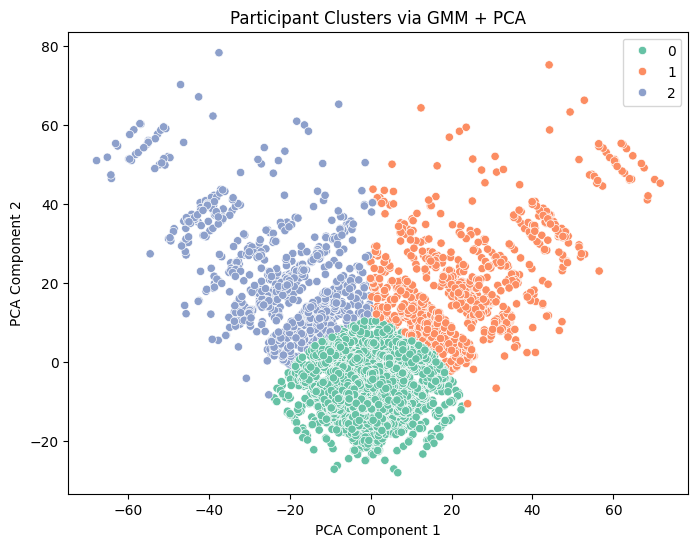

Match rate per cluster:
cluster
0    0.164270
1    0.165441
2    0.166667
Name: match, dtype: float64


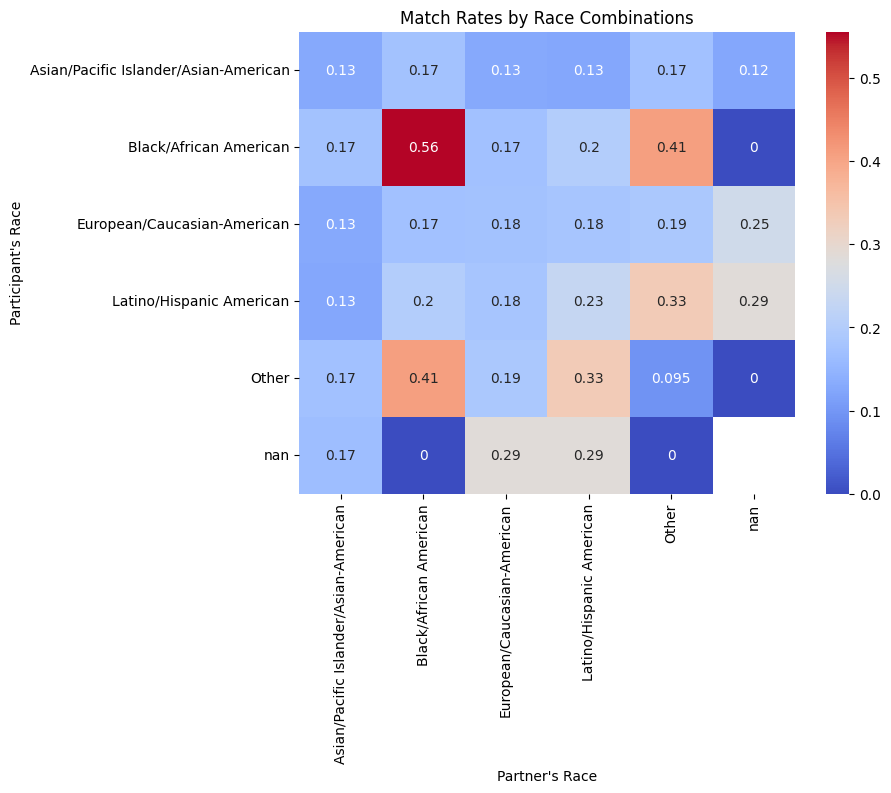

Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1389
           1       1.00      1.00      1.00       287

    accuracy                           1.00      1676
   macro avg       1.00      1.00      1.00      1676
weighted avg       1.00      1.00      1.00      1676

Random Forest ROC AUC Score: 1.0


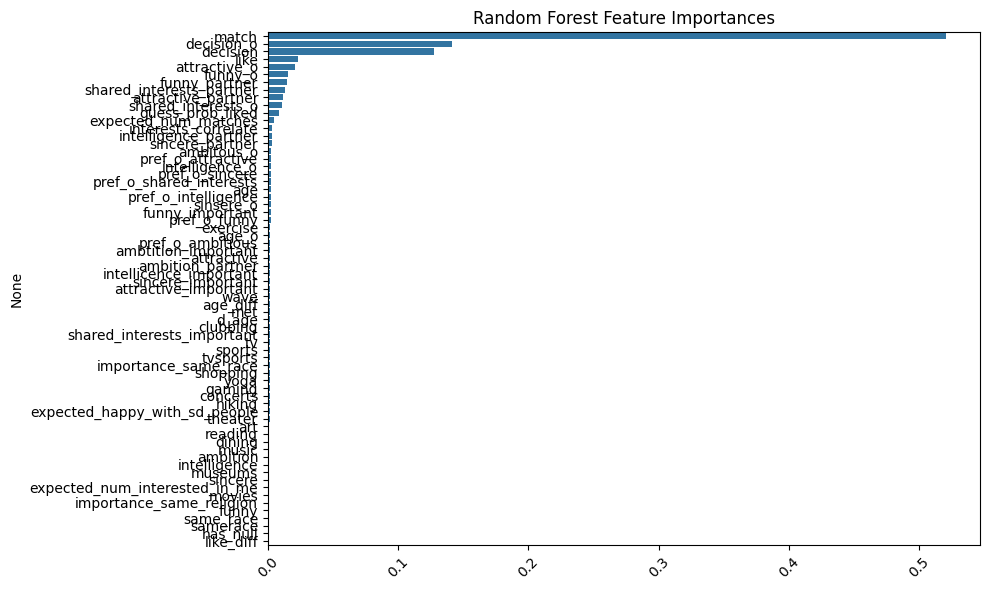

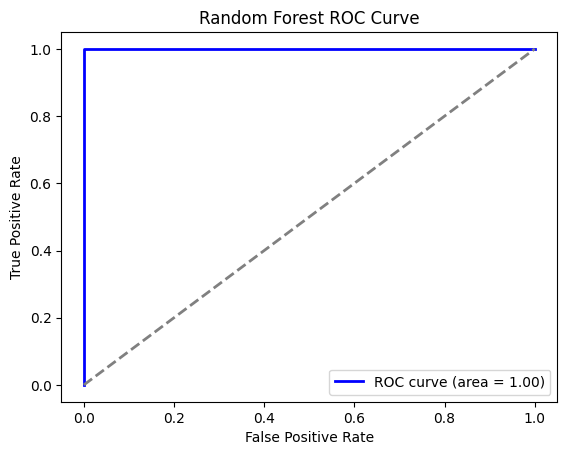

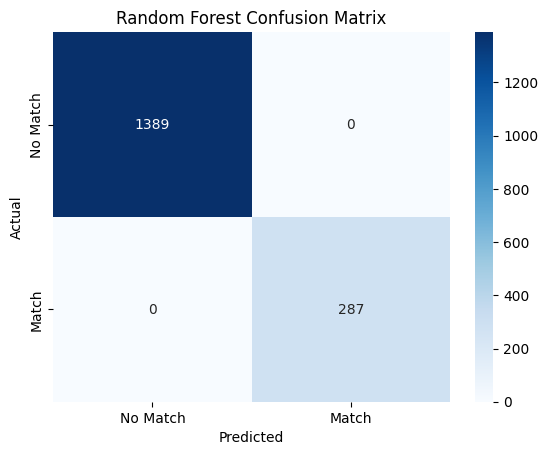

<Figure size 640x480 with 0 Axes>

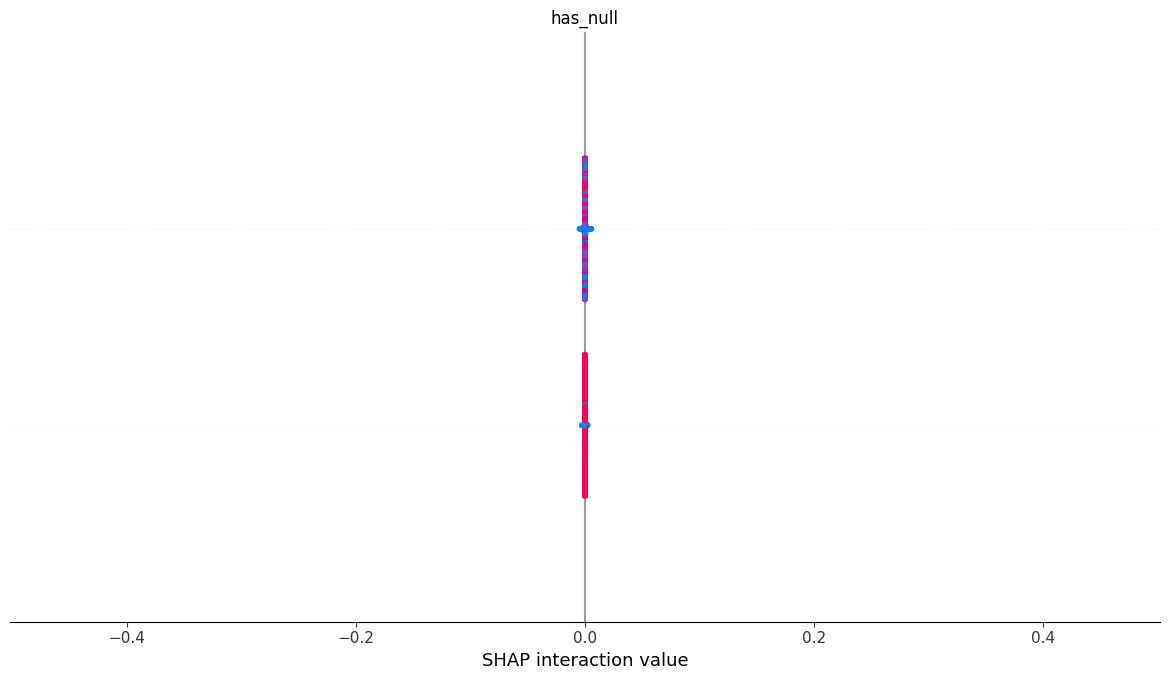

XGBoost Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1389
           1       1.00      1.00      1.00       287

    accuracy                           1.00      1676
   macro avg       1.00      1.00      1.00      1676
weighted avg       1.00      1.00      1.00      1676

XGBoost ROC AUC Score: 1.0


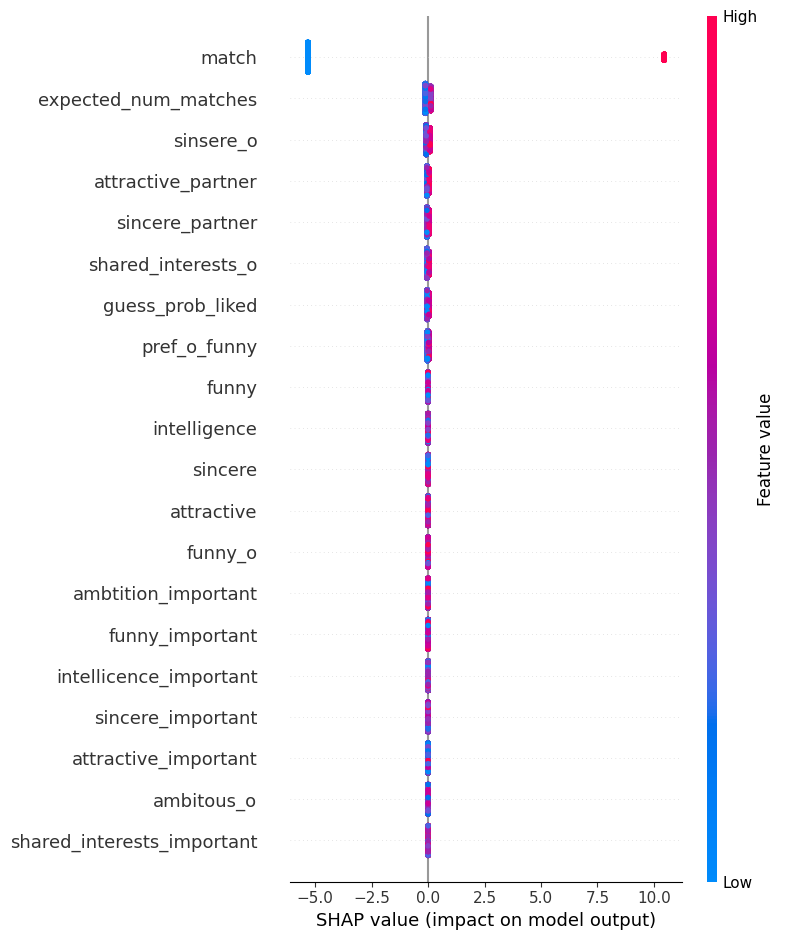


Model Accuracy Comparison:
Random Forest Accuracy: 1.000
XGBoost Accuracy: 1.000
Random Forest ROC AUC: 1.000
XGBoost ROC AUC: 1.000


In [29]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, auc, 
    confusion_matrix, accuracy_score
)

# Loaded CSV data
csv_file_path = "/Users/odettesaenz/Downloads/SpeedDating.csv"
df = pd.read_csv(csv_file_path)

print(df.columns)

# Recomputing the 'match' column
if 'decision' in df.columns and 'decision_o' in df.columns:
    df['match'] = ((df['decision'] == 1) & (df['decision_o'] == 1)).astype(int)
else:
    raise KeyError("Missing 'decision' or 'decision_o' column in dataset.")

# Cleaning the race labels
df['race'] = df['race'].astype(str).str.strip("'")
df['race_o'] = df['race_o'].astype(str).str.strip("'")

# Converting to numeric
df_numeric = df.apply(pd.to_numeric, errors='coerce')
X_raw = df_numeric.select_dtypes(include='number')
X_raw = X_raw.loc[:, X_raw.notnull().any()]

# Imputing the missing values
imputer = SimpleImputer(strategy='mean')
X_imputed_array = imputer.fit_transform(X_raw)
X_imputed = pd.DataFrame(X_imputed_array, columns=X_raw.columns)

# Engineered features
X_imputed['age_diff'] = abs(X_imputed['age'] - X_imputed['age_o'])
if 'd_like' in X_imputed.columns:
    X_imputed['like_diff'] = abs(X_imputed['like'] - X_imputed['d_like'])
else:
    print("d_like column is missing!")
    X_imputed['like_diff'] = 0

# same_race feature
if 'race' in df.columns and 'race_o' in df.columns:
    X_imputed['same_race'] = (df['race'] == df['race_o']).astype(int).reset_index(drop=True)

X_full = X_imputed.reset_index(drop=True)
y = df['match'].reset_index(drop=True)

# Checks for match balance
print("Match rate in dataset:", y.mean())

# PCA + GMM
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_full)
gmm = GaussianMixture(n_components=3, random_state=42)
clusters = gmm.fit_predict(X_pca)
df['cluster'] = clusters

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set2')
plt.title("Participant Clusters via GMM + PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.savefig("cluster_plot.png", dpi=300)
plt.show()

# Cluster-wise match rate
print("Match rate per cluster:")
print(df.groupby("cluster")["match"].mean())

# Heatmap of match rates by race combinations
heatmap_data = df.pivot_table(index='race', columns='race_o', values='match', aggfunc='mean')
if not heatmap_data.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data, cmap='coolwarm', annot=True)
    plt.title("Match Rates by Race Combinations")
    plt.xlabel("Partner's Race")
    plt.ylabel("Participant's Race")
    plt.savefig("race_match_heatmap.png", dpi=300)
    plt.show()
else:
    print("Heatmap not shown: no valid data after pivoting.")

# Train/test splits
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest ROC AUC Score:", roc_auc_score(y_test, y_pred_rf))

# Feature Importances (RF)
importances = rf_model.feature_importances_
feature_names = X_train.columns
sorted_idx = importances.argsort()[::-1]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_idx], y=feature_names[sorted_idx])
plt.title("Random Forest Feature Importances")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("rf_feature_importances.png", dpi=300)
plt.show()

# ROC Curve (RF)
fpr, tpr, _ = roc_curve(y_test, y_pred_rf)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc="lower right")
plt.savefig("rf_roc_curve.png", dpi=300)
plt.show()

# Confusion Matrix (RF)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Match', 'Match'], yticklabels=['No Match', 'Match'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.savefig("rf_conf_matrix.png", dpi=300)
plt.show()

# SHAP - Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_train)
else:
    shap.summary_plot(shap_values, X_train)

# XGBoost
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb))
print("XGBoost ROC AUC Score:", roc_auc_score(y_test, y_pred_xgb))

# SHAP - XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)
shap.summary_plot(shap_values_xgb, X_train)

# Model Comparison Summary
print("\nModel Accuracy Comparison:")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"Random Forest ROC AUC: {roc_auc_score(y_test, y_pred_rf):.3f}")
print(f"XGBoost ROC AUC: {roc_auc_score(y_test, y_pred_xgb):.3f}")

In [25]:
# DEBUG: Checking for valid data before creating heatmap
print("Checking for valid 'race', 'race_o', and 'match' values:")
print(df[['race', 'race_o', 'match']].dropna().head(10))  # Show first 10 rows of valid data

print("\nValue counts:")
print("race:", df['race'].value_counts(dropna=False))
print("race_o:", df['race_o'].value_counts(dropna=False))
print("match:", df['match'].value_counts(dropna=False))

print(df.columns)



Checking for valid 'race', 'race_o', and 'match' values:
Empty DataFrame
Columns: [race, race_o, match]
Index: []

Value counts:
race: race
European/Caucasian-American                4727
'Asian/Pacific Islander/Asian-American'    1982
'Latino/Hispanic American'                  664
Other                                       522
'Black/African American'                    420
NaN                                          63
Name: count, dtype: int64
race_o: race_o
European/Caucasian-American                4722
'Asian/Pacific Islander/Asian-American'    1978
'Latino/Hispanic American'                  664
Other                                       521
'Black/African American'                    420
NaN                                          73
Name: count, dtype: int64
match: match
NaN    8378
Name: count, dtype: int64
Index(['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age',
       'race', 'race_o', 'samerace',
       ...
       'd_expected_num_matches', 'like', 'gue